**Updated Model**

In [ ]:
# Converts the provided QueryResults-based code to work with output_Live_preprocessed.csv
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Optional fallback
from sklearn.feature_extraction.text import TfidfVectorizer

# Try to import Top2Vec
try:
    from top2vec import Top2Vec
    HAS_T2V = True
except Exception:
    HAS_T2V = False

SEED = 42
np.random.seed(SEED)

# Paths
SRC1 = 'original_Jumbo.csv'
SRC2 = os.path.join('Datasets', 'Preprocessed Datasets', 'output_Live_preprocessed.csv')
if not os.path.exists(SRC1):
    if os.path.exists(SRC2):
        SRC1 = SRC2
    else:
        raise FileNotFoundError(f'CSV not found at {SRC1} or {SRC2}')

# Load and normalize columns
raw = pd.read_csv(SRC1)

# Ensure expected columns exist
if 'question_id' not in raw.columns:
    raise KeyError("Expected 'question_id' column not found.")
if 'question_text' not in raw.columns:
    raise KeyError("Expected 'question_text' column not found.")

# Parse list-like string cells to plain text

def safe_parse_list_string(s):
    if isinstance(s, str):
        st = s.strip()
        if st.startswith('[') and st.endswith(']'):
            try:
                val = ast.literal_eval(st)
                return val if isinstance(val, list) else None
            except (ValueError, SyntaxError):
                return None
    return None

def process_text_cell(item):
    parsed = safe_parse_list_string(item)
    if parsed is not None:
        return ' '.join(str(w) for w in parsed)
    return item.strip() if isinstance(item, str) else ''

raw['question_text'] = raw['question_text'].apply(process_text_cell)
answer_cols = [f'answer_item_{i}' for i in range(1, 10) if f'answer_item_{i}' in raw.columns]
for c in answer_cols:
    raw[c] = raw[c].apply(process_text_cell)

# Build documents: include all questions and all answers as separate docs
documents = raw['question_text'].tolist()
for c in answer_cols:
    documents.extend(raw[c][raw[c].str.strip() != ''].tolist())

# Fit model or fallback vectorizer
model = None
if HAS_T2V:
    try:
        # Some versions accept random_state, others don't
        model = Top2Vec(documents=documents, speed='learn', embedding_model='doc2vec', workers=4, random_state=SEED)
    except TypeError:
        try:
            model = Top2Vec(documents=documents, speed='learn', embedding_model='doc2vec', workers=4)
        except TypeError:
            # Final minimal fallback
            model = Top2Vec(documents=documents, workers=4)
    except Exception as e:
        print('Top2Vec init failed, falling back to TF‑IDF.', e)
        model = None
        HAS_T2V = False

if model is None:
    HAS_T2V = False

if HAS_T2V:
    # Robust embedding for arbitrary text across Top2Vec versions
    def get_embedding(text: str):
        if hasattr(model, 'embed_documents'):
            vecs = model.embed_documents([text])
            arr = np.asarray(vecs)
        elif hasattr(model, '_embed_documents'):
            vecs = model._embed_documents([text])
            arr = np.asarray(vecs)
        elif hasattr(model, '_infer_vector'):
            arr = np.asarray(model._infer_vector([text]))
        else:
            # As a last resort, try to add the text to TF‑IDF
            raise AttributeError('No suitable Top2Vec embedding method found')
        # Ensure 2D for cosine_similarity
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        return arr
else:
    # TF‑IDF fallback
    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    tfidf.fit(documents)
    def get_embedding(text: str):
        return tfidf.transform([text])

# Score answers by cosine similarity to their question
results = []
for _, r in raw.iterrows():
    qid = r['question_id']
    qtxt = r['question_text']
    if not isinstance(qtxt, str) or not qtxt.strip():
        continue
    try:
        q_vec = get_embedding(qtxt)
    except Exception as e:
        # If Top2Vec embed failed dynamically, fall back to TF‑IDF on the fly
        if HAS_T2V:
            print('Embedding fallback to TF‑IDF due to error:', e)
            tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
            tfidf.fit(documents)
            def get_embedding(text: str):
                return tfidf.transform([text])
            q_vec = get_embedding(qtxt)
        else:
            raise

    score_row = {'question_id': qid, 'question_text': qtxt}
    for c in answer_cols:
        ans = r.get(c, '')
        if not isinstance(ans, str) or not ans.strip():
            continue
        a_vec = get_embedding(ans)
        # Cosine similarity as relevance score
        try:
            sim = float(cosine_similarity(q_vec, a_vec)[0][0])
        except Exception:
            # In sparse/dense mismatch, coerce to dense
            qv = q_vec.toarray() if hasattr(q_vec, 'toarray') else np.asarray(q_vec)
            av = a_vec.toarray() if hasattr(a_vec, 'toarray') else np.asarray(a_vec)
            sim = float(cosine_similarity(qv, av)[0][0])
        # Convert similarity (-1..1) to percentage (0..100)
        score_row[c + '_score'] = (sim + 1.0) / 2.0 * 100.0
    results.append(score_row)

output_df = pd.DataFrame(results)
out_path = 'Answer_Relevance_Scores-4.csv'
output_df.to_csv(out_path, index=False)
print('Saved scores ->', out_path)
print(output_df.head())

Saved scores -> Answer_Relevance_Scores-4.csv
   question_id                                      question_text  \
0            1  Organization choose concern now eye stage othe...   
1            2  Between certainly turn marriage consider envir...   
2            3                 Marriage best film dream why wish.   
3            4  Guess no soon but hair company letter fund mis...   
4            5  Myself know after say Congress view wear amoun...   

   answer_item_1_score  answer_item_2_score  answer_item_3_score  \
0            50.000000            50.000000            50.000000   
1            50.000000            52.776596            50.000000   
2            50.000000            50.000000            50.000000   
3            52.864142            50.000000            50.000000   
4            50.000000            50.000000            53.136759   

   answer_item_4_score  answer_item_5_score  answer_item_6_score  \
0                 50.0            50.000000                 50

In [ ]:
# Converts the provided QueryResults-based code to work with output_Live_preprocessed.csv
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Optional fallback
from sklearn.feature_extraction.text import TfidfVectorizer

# Try to import Top2Vec
try:
    from top2vec import Top2Vec
    HAS_T2V = True
except Exception:
    HAS_T2V = False

SEED = 42
np.random.seed(SEED)

# -------- Config (tune to your Top2Vec version) --------
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'  # alternatives: 'doc2vec', 'universal-sentence-encoder', etc.
SPEED = 'fast-learn'                  # for SBERT models; use 'learn' for doc2vec
WORKERS = 4

# Paths
SRC1 = 'QueryResults-2.csv'
SRC2 = os.path.join('Datasets', 'Preprocessed Datasets', 'output_Live_preprocessed.csv')
if not os.path.exists(SRC1):
    if os.path.exists(SRC2):
        SRC1 = SRC2
    else:
        raise FileNotFoundError(f'CSV not found at {SRC1} or {SRC2}')

# Load and normalize columns
raw = pd.read_csv(SRC1)

# Ensure expected columns exist
if 'question_id' not in raw.columns:
    raise KeyError("Expected 'question_id' column not found.")
if 'question_text' not in raw.columns:
    raise KeyError("Expected 'question_text' column not found.")

# Parse list-like string cells to plain text

def safe_parse_list_string(s):
    if isinstance(s, str):
        st = s.strip()
        if st.startswith('[') and st.endswith(']'):
            try:
                val = ast.literal_eval(st)
                return val if isinstance(val, list) else None
            except (ValueError, SyntaxError):
                return None
    return None

def process_text_cell(item):
    parsed = safe_parse_list_string(item)
    if parsed is not None:
        return ' '.join(str(w) for w in parsed)
    return item.strip() if isinstance(item, str) else ''

raw['question_text'] = raw['question_text'].apply(process_text_cell)
answer_cols = [f'answer_item_{i}' for i in range(1, 10) if f'answer_item_{i}' in raw.columns]
for c in answer_cols:
    raw[c] = raw[c].apply(process_text_cell)

# Build documents: include all questions and all answers as separate docs
documents = raw['question_text'].tolist()
for c in answer_cols:
    documents.extend(raw[c][raw[c].str.strip() != ''].tolist())

# -------- Fit model or fallback vectorizer --------
model = None
if HAS_T2V:
    try:
        model = Top2Vec(documents=documents, speed=SPEED, embedding_model=EMBEDDING_MODEL, workers=WORKERS)
    except TypeError:
        try:
            model = Top2Vec(documents=documents, speed=SPEED, workers=WORKERS)
        except TypeError:
            model = Top2Vec(documents=documents, workers=WORKERS)
    except Exception as e:
        print('Top2Vec init failed, falling back to TF‑IDF.', e)
        model = None
        HAS_T2V = False

if model is None:
    HAS_T2V = False

if HAS_T2V:
    # Robust embedding for arbitrary text across Top2Vec versions
    def get_embedding(text: str):
        if hasattr(model, 'embed_documents'):
            arr = np.asarray(model.embed_documents([text]))
        elif hasattr(model, '_embed_documents'):
            arr = np.asarray(model._embed_documents([text]))
        elif hasattr(model, '_infer_vector'):
            arr = np.asarray(model._infer_vector([text]))
        else:
            raise AttributeError('No suitable Top2Vec embedding method found')
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        return arr
else:
    # TF‑IDF fallback
    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    tfidf.fit(documents)
    def get_embedding(text: str):
        return tfidf.transform([text])

# -------- Score answers by cosine similarity to their question --------
results = []
for _, r in raw.iterrows():
    qid = r['question_id']
    qtxt = r['question_text']
    if not isinstance(qtxt, str) or not qtxt.strip():
        continue
    try:
        q_vec = get_embedding(qtxt)
    except Exception as e:
        # If Top2Vec embed failed dynamically, fall back to TF‑IDF on the fly
        if HAS_T2V:
            print('Embedding fallback to TF‑IDF due to error:', e)
            tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
            tfidf.fit(documents)
            def get_embedding(text: str):
                return tfidf.transform([text])
            q_vec = get_embedding(qtxt)
        else:
            raise

    score_row = {'question_id': qid, 'question_text': qtxt}
    for c in answer_cols:
        ans = r.get(c, '')
        if not isinstance(ans, str) or not ans.strip():
            continue
        a_vec = get_embedding(ans)
        try:
            sim = float(cosine_similarity(q_vec, a_vec)[0][0])
        except Exception:
            qv = q_vec.toarray() if hasattr(q_vec, 'toarray') else np.asarray(q_vec)
            av = a_vec.toarray() if hasattr(a_vec, 'toarray') else np.asarray(a_vec)
            sim = float(cosine_similarity(qv, av)[0][0])
        score_row[c + '_score'] = (sim + 1.0) / 2.0 * 100.0
    results.append(score_row)

output_df = pd.DataFrame(results)
out_path = 'Answer_Relevance_Scores.csv'
output_df.to_csv(out_path, index=False)
print('Saved scores ->', out_path)
print(output_df.head())

Saved scores -> Answer_Relevance_Scores.csv
   question_id                                      question_text  \
0        48859  Is it doable to train LLMs locally with 54 nov...   
1        48846  Why do we expect AI to reason instantly when h...   
2        48833  How are so many people able to train AIs if th...   
3        48788  If artificial intelligence surpasses human int...   
4        48117                Are LLMs "lazy" in their responses?   

   answer_item_1_score  answer_item_2_score  answer_item_3_score  \
0            53.386680            58.484482            50.300768   
1            64.897839            60.413683            52.338828   
2            52.109230            51.239879            50.350623   
3            56.155830            50.845344            51.507281   
4            50.299960            51.230068            50.143914   

   answer_item_4_score  answer_item_5_score  answer_item_6_score  \
0            51.825869            50.710613                  NaN

In [ ]:
# Converts the provided QueryResults-based code to work with output_Live_preprocessed.csv
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Optional fallback
from sklearn.feature_extraction.text import TfidfVectorizer

# Try to import Top2Vec
try:
    from top2vec import Top2Vec
    HAS_T2V = True
except Exception:
    HAS_T2V = False

SEED = 42
np.random.seed(SEED)

# Paths
SRC1 = 'QueryResults-2.csv'
SRC2 = os.path.join('Datasets', 'Preprocessed Datasets', 'QueryResults-2.csv')
if not os.path.exists(SRC1):
    if os.path.exists(SRC2):
        SRC1 = SRC2
    else:
        raise FileNotFoundError(f'CSV not found at {SRC1} or {SRC2}')

# Load and normalize columns
raw = pd.read_csv(SRC1)

# Ensure expected columns exist
if 'question_id' not in raw.columns:
    raise KeyError("Expected 'question_id' column not found.")
if 'question_text' not in raw.columns:
    raise KeyError("Expected 'question_text' column not found.")

# Parse list-like string cells to plain text

def safe_parse_list_string(s):
    if isinstance(s, str):
        st = s.strip()
        if st.startswith('[') and st.endswith(']'):
            try:
                val = ast.literal_eval(st)
                return val if isinstance(val, list) else None
            except (ValueError, SyntaxError):
                return None
    return None

def process_text_cell(item):
    parsed = safe_parse_list_string(item)
    if parsed is not None:
        return ' '.join(str(w) for w in parsed)
    return item.strip() if isinstance(item, str) else ''

raw['question_text'] = raw['question_text'].apply(process_text_cell)
answer_cols = [f'answer_item_{i}' for i in range(1, 10) if f'answer_item_{i}' in raw.columns]
for c in answer_cols:
    raw[c] = raw[c].apply(process_text_cell)

# Build documents: include all questions and all answers as separate docs
documents = raw['question_text'].tolist()
for c in answer_cols:
    documents.extend(raw[c][raw[c].str.strip() != ''].tolist())

# Fit model or fallback vectorizer
model = None
if HAS_T2V:
    try:
        # Some versions accept random_state, others don't
        model = Top2Vec(documents=documents, speed='learn', embedding_model='doc2vec', workers=4, random_state=SEED)
    except TypeError:
        try:
            model = Top2Vec(documents=documents, speed='learn', embedding_model='doc2vec', workers=4)
        except TypeError:
            # Final minimal fallback
            model = Top2Vec(documents=documents, workers=4)
    except Exception as e:
        print('Top2Vec init failed, falling back to TF‑IDF.', e)
        model = None
        HAS_T2V = False

if model is None:
    HAS_T2V = False

if HAS_T2V:
    # Robust embedding for arbitrary text across Top2Vec versions
    def get_embedding(text: str):
        if hasattr(model, 'embed_documents'):
            vecs = model.embed_documents([text])
            arr = np.asarray(vecs)
        elif hasattr(model, '_embed_documents'):
            vecs = model._embed_documents([text])
            arr = np.asarray(vecs)
        elif hasattr(model, '_infer_vector'):
            arr = np.asarray(model._infer_vector([text]))
        else:
            # As a last resort, try to add the text to TF‑IDF
            raise AttributeError('No suitable Top2Vec embedding method found')
        # Ensure 2D for cosine_similarity
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        return arr
else:
    # TF‑IDF fallback
    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    tfidf.fit(documents)
    def get_embedding(text: str):
        return tfidf.transform([text])

# Score answers by cosine similarity to their question
results = []
for _, r in raw.iterrows():
    qid = r['question_id']
    qtxt = r['question_text']
    if not isinstance(qtxt, str) or not qtxt.strip():
        continue
    try:
        q_vec = get_embedding(qtxt)
    except Exception as e:
        # If Top2Vec embed failed dynamically, fall back to TF‑IDF on the fly
        if HAS_T2V:
            print('Embedding fallback to TF‑IDF due to error:', e)
            tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
            tfidf.fit(documents)
            def get_embedding(text: str):
                return tfidf.transform([text])
            q_vec = get_embedding(qtxt)
        else:
            raise

    score_row = {'question_id': qid, 'question_text': qtxt}
    for c in answer_cols:
        ans = r.get(c, '')
        if not isinstance(ans, str) or not ans.strip():
            continue
        a_vec = get_embedding(ans)
        # Cosine similarity as relevance score
        try:
            sim = float(cosine_similarity(q_vec, a_vec)[0][0])
        except Exception:
            # In sparse/dense mismatch, coerce to dense
            qv = q_vec.toarray() if hasattr(q_vec, 'toarray') else np.asarray(q_vec)
            av = a_vec.toarray() if hasattr(a_vec, 'toarray') else np.asarray(av)
            sim = float(cosine_similarity(qv, av)[0][0])
        # Convert similarity (-1..1) to percentage (0..100)
        score_row[c + '_score'] = (sim + 1.0) / 2.0 * 100.0
    results.append(score_row)

output_df = pd.DataFrame(results)
out_path = 'Answer_Relevance_Scores.csv'
output_df.to_csv(out_path, index=False)
print('Saved scores ->', out_path)
print(output_df.head())

Saved scores -> Answer_Relevance_Scores.csv
   question_id                                      question_text  \
0        48859  Is it doable to train LLMs locally with 54 nov...   
1        48846  Why do we expect AI to reason instantly when h...   
2        48833  How are so many people able to train AIs if th...   
3        48788  If artificial intelligence surpasses human int...   
4        48117                Are LLMs "lazy" in their responses?   

   answer_item_1_score  answer_item_2_score  answer_item_3_score  \
0            53.386680            58.484482            50.300768   
1            64.897839            60.413683            52.338828   
2            52.109230            51.239879            50.350623   
3            56.155830            50.845344            51.507281   
4            50.299960            51.230068            50.143914   

   answer_item_4_score  answer_item_5_score  answer_item_6_score  \
0            51.825869            50.710613                  NaN

Using: Answer_Relevance_Scores-4.csv
Shape: (1000, 11)
Columns: ['question_id', 'question_text', 'answer_item_1_score', 'answer_item_2_score', 'answer_item_3_score', 'answer_item_4_score', 'answer_item_5_score', 'answer_item_6_score', 'answer_item_7_score', 'answer_item_8_score', 'answer_item_9_score']

Score columns describe():
                      count       mean       std   min   25%   50%   75%  \
answer_item_1_score  1000.0  50.374407  0.977553  50.0  50.0  50.0  50.0   
answer_item_2_score  1000.0  50.399305  1.051701  50.0  50.0  50.0  50.0   
answer_item_3_score  1000.0  50.368712  1.148479  50.0  50.0  50.0  50.0   
answer_item_4_score   849.0  50.363036  1.000727  50.0  50.0  50.0  50.0   
answer_item_5_score   701.0  50.349638  1.061693  50.0  50.0  50.0  50.0   
answer_item_6_score   571.0  50.422929  1.122525  50.0  50.0  50.0  50.0   
answer_item_7_score   451.0  50.418703  1.117074  50.0  50.0  50.0  50.0   
answer_item_8_score   303.0  50.403654  0.966372  50.0  50.0 

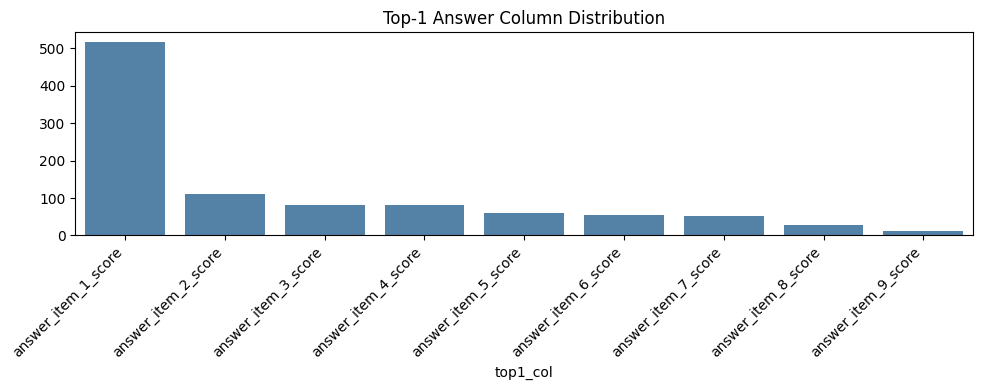

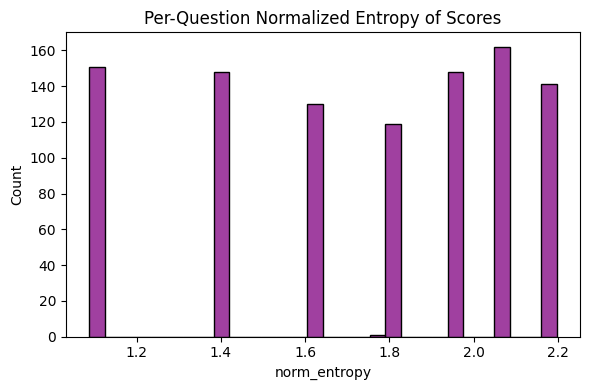

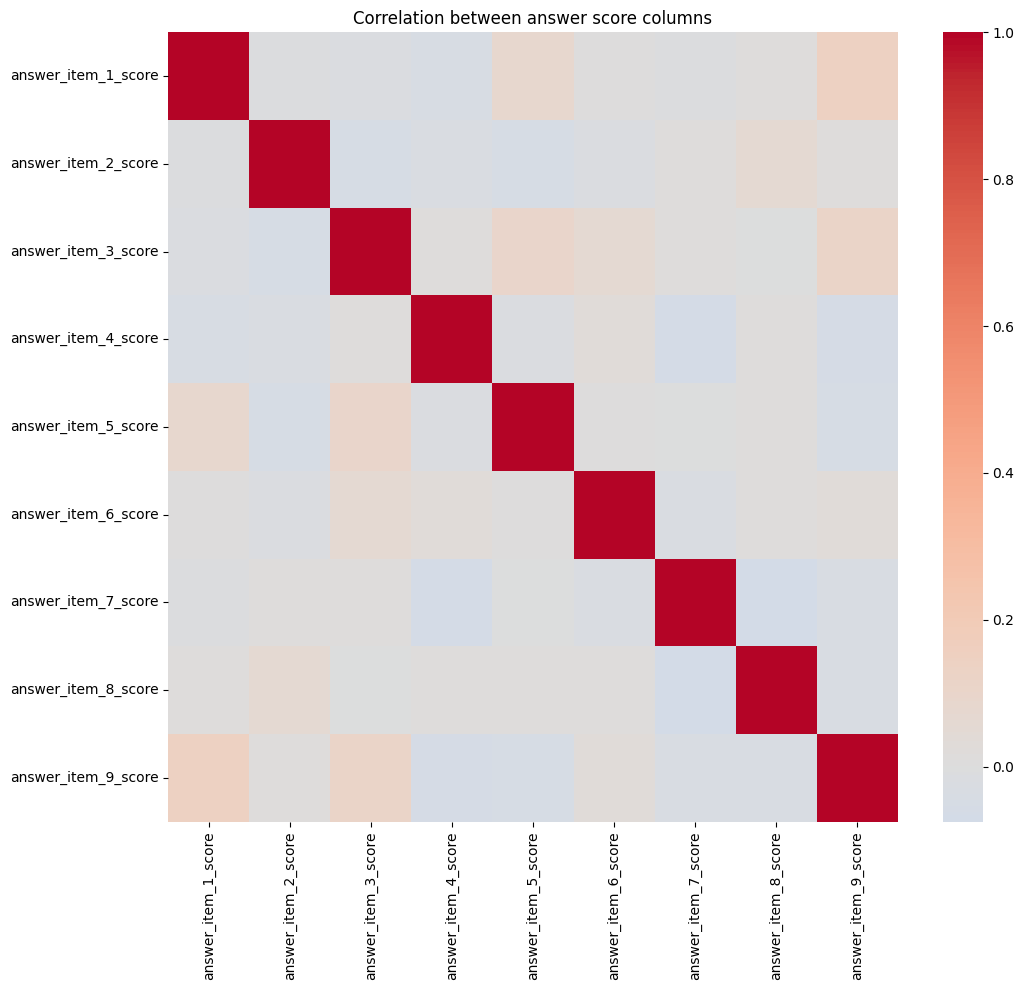

In [ ]:
# Load and analyze the generated scores CSV
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SCORES_PATHS = [
    'Answer_Relevance_Scores-4.csv',
    os.path.join('Datasets', 'Live Datasets', 'Answer_Relevance_Scores.csv')
]

scores_path = None
for p in SCORES_PATHS:
    if os.path.exists(p):
        scores_path = p
        break
if scores_path is None:
    raise FileNotFoundError('Answer_Relevance_Scores.csv not found in working dir or Datasets/Live Datasets/')

print('Using:', scores_path)
scores = pd.read_csv(scores_path)
print('Shape:', scores.shape)
print('Columns:', list(scores.columns))

# Identify score columns
score_cols = [c for c in scores.columns if c.endswith('_score')]
if not score_cols:
    raise ValueError('No *_score columns found in the CSV.')

# Basic stats
desc = scores[score_cols].describe().T
missing = scores[score_cols].isna().sum().sort_values(ascending=False)
print('\nScore columns describe():')
print(desc)
print('\nMissing values by column:')
print(missing.head(15))

# Top-1 winner per question

def top1_idx(row):
    vals = {c: row[c] for c in score_cols if pd.notna(row[c])}
    if not vals:
        return None
    return max(vals, key=vals.get)

scores['top1_col'] = scores.apply(top1_idx, axis=1)

# Distribution of top-1 answer indices
try:
    idx_counts = scores['top1_col'].value_counts(dropna=True)
    print('\nTop-1 answer column distribution:')
    print(idx_counts)
    plt.figure(figsize=(10,4))
    sns.barplot(x=idx_counts.index, y=idx_counts.values, color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top-1 Answer Column Distribution')
    plt.tight_layout()
    plt.savefig('top1_answer_column_distribution.png')
    print('Saved top1_answer_column_distribution.png')
except Exception as e:
    print('Top-1 distribution plotting skipped:', e)

# Normalize per question (prob-like) and compute entropy (concentration)

vals = scores[score_cols].fillna(0.0).clip(lower=0.0)
row_sums = vals.sum(axis=1).replace(0, np.nan)
probs = vals.div(row_sums, axis=0)

entropy = -(probs * np.log(probs.replace(0, np.nan))).sum(axis=1)
scores['norm_entropy'] = entropy.fillna(0.0)
print('\nEntropy stats (lower => more confident top-1):')
print(scores['norm_entropy'].describe())

plt.figure(figsize=(6,4))
sns.histplot(scores['norm_entropy'], bins=30, color='purple')
plt.title('Per-Question Normalized Entropy of Scores')
plt.tight_layout()
plt.savefig('normalized_entropy_hist.png')
print('Saved normalized_entropy_hist.png')

# Correlations between answer score columns (pairwise)
try:
    corr = scores[score_cols].corr()
    plt.figure(figsize=(min(12, 2+len(score_cols)), min(10, 2+len(score_cols))))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation between answer score columns')
    plt.tight_layout()
    plt.savefig('score_columns_correlation.png')
    print('Saved score_columns_correlation.png')
except Exception as e:
    print('Correlation heatmap skipped:', e)

# Flag suspicious rows: all NaN, all zeros, ties for top-1
flags = []
for idx, row in scores.iterrows():
    vals = [row[c] for c in score_cols if pd.notna(row[c])]
    if len(vals) == 0:
        flags.append({'row': idx, 'issue': 'all_nan'})
        continue
    if all(v == 0 for v in vals):
        flags.append({'row': idx, 'issue': 'all_zero'})
        continue
    # ties
    maxv = max(vals)
    nmax = sum(1 for v in vals if v == maxv)
    if nmax > 1:
        flags.append({'row': idx, 'issue': f'tie_top1_{nmax}'})

flags_df = pd.DataFrame(flags)
flags_df.to_csv('answer_score_flags.csv', index=False)
print('\nFlagged rows saved to answer_score_flags.csv (first 10 shown):')
print(flags_df.head(10))

# Save enriched analysis CSV
scores.to_csv('Answer_Relevance_Scores_enriched.csv', index=False)
print('Saved Answer_Relevance_Scores_enriched.csv')